In [44]:
import pandas as pd

def show_recs():
    for r in records:
        print(r)

records = []

try:
    with open("firewall_big.log", "r") as file:
        for line in file:
            source = None
            action = None
            dpt = None
            protocol = None
            cleaned_line = line.split()
            for part in cleaned_line:
                if part.startswith("SRC="):
                    source = part.split("=", 1)[1]    
                elif part.startswith("ACTION="):
                    action = part.split("=", 1)[1]
                elif part.startswith("DPT="):
                    dpt = part.split("=", 1)[1]
                elif part.startswith("PROTO="):
                    protocol = part.split("=", 1)[1]
            record = {
                "src_ip": source,
                "action": action,
                "dpt": dpt,
                "protocol": protocol
            }

            records.append(record)     
                
except FileNotFoundError:
  print("File does not exist")  

show_recs()

{'src_ip': '192.168.1.50', 'action': 'ACCEPT', 'dpt': '443', 'protocol': 'TCP'}
{'src_ip': '10.0.0.22', 'action': 'ACCEPT', 'dpt': '53', 'protocol': 'UDP'}
{'src_ip': '192.168.1.35', 'action': 'ACCEPT', 'dpt': '53', 'protocol': 'UDP'}
{'src_ip': '10.0.0.15', 'action': 'ACCEPT', 'dpt': '80', 'protocol': 'TCP'}
{'src_ip': '10.0.0.30', 'action': 'ACCEPT', 'dpt': '80', 'protocol': 'TCP'}
{'src_ip': '192.168.1.35', 'action': 'ACCEPT', 'dpt': '80', 'protocol': 'TCP'}
{'src_ip': '192.168.1.20', 'action': 'ACCEPT', 'dpt': '80', 'protocol': 'TCP'}
{'src_ip': '10.0.0.15', 'action': 'ACCEPT', 'dpt': '53', 'protocol': 'UDP'}
{'src_ip': '192.168.1.50', 'action': 'ACCEPT', 'dpt': '80', 'protocol': 'TCP'}
{'src_ip': '192.168.1.20', 'action': 'ACCEPT', 'dpt': '80', 'protocol': 'TCP'}
{'src_ip': '10.0.0.30', 'action': 'ACCEPT', 'dpt': '80', 'protocol': 'TCP'}
{'src_ip': '192.168.1.50', 'action': 'ACCEPT', 'dpt': '443', 'protocol': 'TCP'}
{'src_ip': '10.0.0.15', 'action': 'ACCEPT', 'dpt': '53', 'protoco

In [45]:
df = pd.DataFrame(records)
df["is_blocked"] = df["action"] != "ACCEPT"
df["is_blocked"].value_counts()

is_blocked
False    120
True      99
Name: count, dtype: int64

In [46]:
group = df.groupby("src_ip").agg(
    total = ("action", "count"),
    unique_ports = ("dpt", "nunique"),
    blocked = ("is_blocked", "sum"),
)
group["blocked_ratio"] = group["blocked"] / group["total"]
group


,total,unique_ports,blocked,blocked_ratio
src_ip,,,,
10.0.0.12,19,3,0,0.0
10.0.0.15,18,3,0,0.0
10.0.0.22,14,3,0,0.0
10.0.0.30,22,2,0,0.0
185.220.101.33,25,1,25,1.0
192.168.1.20,14,3,0,0.0
192.168.1.35,15,3,0,0.0
192.168.1.50,18,3,0,0.0
193.169.255.78,3,3,3,1.0


In [47]:
X = group[["total", "unique_ports", "blocked", "blocked_ratio"]]
X

,total,unique_ports,blocked,blocked_ratio
src_ip,,,,
10.0.0.12,19,3,0,0.0
10.0.0.15,18,3,0,0.0
10.0.0.22,14,3,0,0.0
10.0.0.30,22,2,0,0.0
185.220.101.33,25,1,25,1.0
192.168.1.20,14,3,0,0.0
192.168.1.35,15,3,0,0.0
192.168.1.50,18,3,0,0.0
193.169.255.78,3,3,3,1.0


In [48]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.2, random_state=42)
group["anomaly"] = model.fit_predict(X)
group

,total,unique_ports,blocked,blocked_ratio,anomaly
src_ip,,,,,
10.0.0.12,19,3,0,0.0,1
10.0.0.15,18,3,0,0.0,1
10.0.0.22,14,3,0,0.0,1
10.0.0.30,22,2,0,0.0,1
185.220.101.33,25,1,25,1.0,-1
192.168.1.20,14,3,0,0.0,1
192.168.1.35,15,3,0,0.0,1
192.168.1.50,18,3,0,0.0,1
193.169.255.78,3,3,3,1.0,1


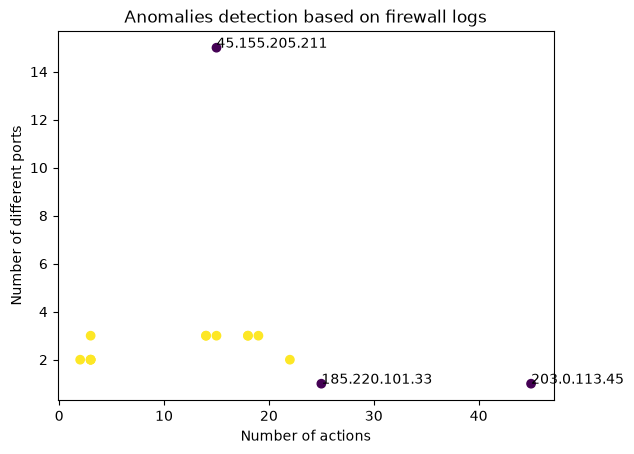

In [49]:
import matplotlib.pyplot as plt

plt.scatter(group["total"], group["unique_ports"], c = group["anomaly"])
plt.xlabel("Number of actions")
plt.ylabel("Number of different ports")
plt.title("Anomalies detection based on firewall logs")
for ip, row in group.iterrows():
    if row["anomaly"] == -1:
        plt.text(row.total, row.unique_ports, ip)
plt.show()
